PCA is one of the most important topic.
PCA (Principal component analysis) is a reduction of dimensionality. its reduce less features and try to preserve important data.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [11]:
df= pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
)
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [12]:
df.shape

(150, 5)

In [13]:
X= df.drop('species', axis=1)
y=df['species'].astype('category').cat.codes

In [14]:
scaler= StandardScaler()
X_scaled= scaler.fit_transform(X)

In [15]:
# --------------------
# Applying Pca
# --------------------
pca= PCA()
X_pca= pca.fit_transform(X_scaled)

In [16]:
# --------------------
# Variance Analysis
# --------------------

explained_variance= pca.explained_variance_ratio_
cumulative_variance= np.cumsum(explained_variance)

print('Explained Variance ratio: \n')
print([f"{x:.2f}" for x in explained_variance])

print("\nCumulative explained variance:")
print([f"{x:.2f}" for x in cumulative_variance])

Explained Variance ratio: 

['0.73', '0.23', '0.04', '0.01']

Cumulative explained variance:
['0.73', '0.96', '0.99', '1.00']


> At least first two principal components giving 96% of the variance. So, we can reduce 4D data to 2D data with minimal reduce.

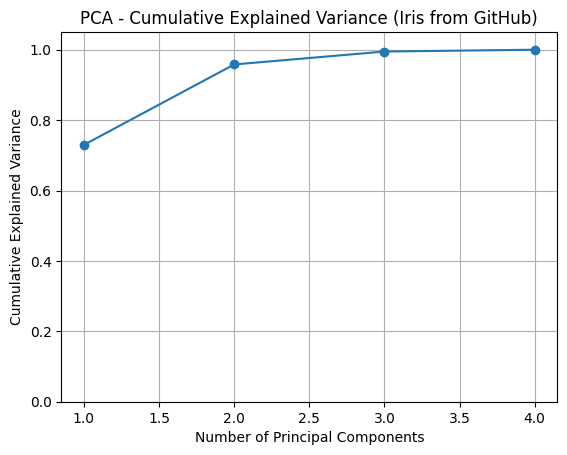

In [17]:
# --------------------------------------
# Plot cumulative variance visualize
# --------------------------------------
plt.figure()
plt.plot(range(1, len(cumulative_variance) + 1),
         cumulative_variance,
         marker='o')

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Cumulative Explained Variance (Iris from GitHub)")
plt.grid(True)
plt.ylim(0, 1.05)
plt.show()

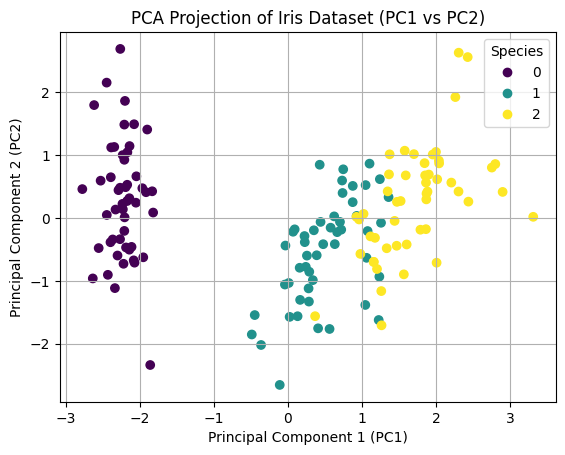

In [18]:
plt.figure()

scatter= plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y

)
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.title("PCA Projection of Iris Dataset (PC1 vs PC2)")
plt.grid(True)
plt.legend(handles=scatter.legend_elements()[0],
    labels=list(y.unique()),
    title="Species")
plt.show()